# XGBoost Fraud Classifier — Behavior Agent, supervised branch

Trains the **supervised primary model** of the Behavior Agent on the 400k labeled
transactions. Sibling to `isolation_forest_transactions_raw.ipynb` (the unsupervised
branch); both feed the Behavior Agent's ensemble blend later, so artifact formats are
kept consistent (same `models/` folder, same feature-manifest style, scored output
joinable on `txn_id`).

Pipeline: load + verify → join + dedupe → leakage-aware nulls → feature engineering →
encoding → **data-audit GO/NO-GO** → time-split train (weighted, no resampling) →
evaluate (PR-AUC first) → SHAP → save + read-back verify.


## Cell 0 — Setup: imports + environment-aware paths

All configurable constants live here. Colab reads/writes Drive; a local run walks up
from cwd to find `backend/datasets/`.


In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report,
)

# shap>=0.52 required for numpy 2.4+ (older shap crashes on import).
# Colab fallback: pip install shap matplotlib if the kernel env is bare.
try:
    import shap
except (ImportError, TypeError):
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap>=0.52", "matplotlib"])
    import shap

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR      = "/content/drive/MyDrive/datasets"
    PROCESSED_DIR = "/content/drive/MyDrive/datasets_processed"
    MODEL_DIR     = "/content/drive/MyDrive/models"
else:
    # Local run: walk up from cwd until we find the backend dir (the one holding datasets/).
    base = Path.cwd()
    while not (base / "datasets" / "transactions_raw.csv").exists():
        if base.parent == base:
            raise FileNotFoundError(
                "Could not locate backend/datasets/transactions_raw.csv above "
                f"{Path.cwd()} — run this notebook from backend/ or backend/notebooks/."
            )
        base = base.parent
    DATA_DIR      = str(base / "datasets")
    PROCESSED_DIR = str(base / "datasets_processed")
    MODEL_DIR     = str(base / "models")

TXNS_PATH     = os.path.join(DATA_DIR, "transactions_raw.csv")
LABELS_PATH   = os.path.join(DATA_DIR, "fraud_labels_train.csv")
PROFILES_PATH = os.path.join(DATA_DIR, "customer_profiles.csv")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE          = 42
EXPECTED_TXN_ROWS     = 2_000_000   # transactions_raw has silently truncated on upload before
EXPECTED_LABELED_ROWS = 400_000
EXPECTED_PROFILES     = 50_000
EXPECTED_FRAUD_RATE   = 0.0183      # 7,338 fraud / 400k — verified ground truth
TRAIN_FRACTION        = 0.80        # time-based: earlier 80% train, later 20% validation

pd.set_option("display.width", 160)
print("[CHECKPOINT] Setup OK —", "Colab/Drive" if IN_COLAB else "local repo run")
print("  data   :", DATA_DIR)
print("  outputs:", PROCESSED_DIR, "|", MODEL_DIR)


[CHECKPOINT] Setup OK — local repo run
  data   : /Users/dikshanta/Documents/Agentic-Fraud-Detection-System-/backend/datasets
  outputs: /Users/dikshanta/Documents/Agentic-Fraud-Detection-System-/backend/datasets_processed | /Users/dikshanta/Documents/Agentic-Fraud-Detection-System-/backend/models


## Step 1 — Load + verify row counts

`transactions_raw.csv` has silently truncated on upload before — hard-stop if short.
From the labels file we keep **only `txn_id` + `is_fraud`**; every other column
(`fraud_type`, `fraud_confidence`, `confirmed_by`, `fraud_date_confirmed`,
`financial_loss_npr`, `recovery_status`) is post-hoc — it only exists *after* fraud was
confirmed, so using any of them as a feature is target leakage. `fraud_type` is kept
aside for **reporting only** (per-type recall in Step 8), never as a feature.


In [2]:
txns = pd.read_csv(TXNS_PATH, parse_dates=["timestamp"], low_memory=False)
labels = pd.read_csv(LABELS_PATH, low_memory=False)
profiles = pd.read_csv(PROFILES_PATH, parse_dates=["customer_since", "last_profile_update"],
                       low_memory=False)

print("[CHECKPOINT] Loaded:", txns.shape, labels.shape, profiles.shape)

# Guard against a silently truncated Drive upload — STOP here if short.
assert len(txns) == EXPECTED_TXN_ROWS, (
    f"transactions_raw row count {len(txns):,} != {EXPECTED_TXN_ROWS:,} — file is "
    "truncated/corrupted. Re-upload before continuing."
)
assert len(labels) == EXPECTED_LABELED_ROWS, (
    f"fraud_labels_train row count {len(labels):,} != {EXPECTED_LABELED_ROWS:,}"
)
assert len(profiles) == EXPECTED_PROFILES, (
    f"customer_profiles row count {len(profiles):,} != {EXPECTED_PROFILES:,}"
)
assert txns["timestamp"].isna().sum() == 0, "timestamp failed to parse on some rows"

# LEAKAGE RULE 1: keep only the key + target; fraud_type aside for reporting ONLY.
labels["is_fraud"] = labels["is_fraud"].astype(int)
labels_clean = labels[["txn_id", "is_fraud"]].copy()
fraud_type_report = labels[["txn_id", "fraud_type"]].copy()   # never joins the feature matrix

fraud_rate = labels_clean["is_fraud"].mean()
print(f"[CHECKPOINT] Labeled universe: {len(labels_clean):,} rows | "
      f"fraud = {labels_clean['is_fraud'].sum():,} ({fraud_rate:.2%})")
print("[CHECKPOINT] Transactions span:", txns["timestamp"].min(), "->", txns["timestamp"].max())


[CHECKPOINT] Loaded: (2000000, 19) (400000, 8) (50000, 19)
[CHECKPOINT] Labeled universe: 400,000 rows | fraud = 7,338 (1.83%)
[CHECKPOINT] Transactions span: 2025-01-01 00:00:12.274000 -> 2026-05-31 23:59:58.484000


## Step 2 — Join + dedupe + freeze the time split

Join order: `labels_clean` → `transactions_raw` (inner on `txn_id`) → `customer_profiles`
(left on `account_id`). Both orphan counts were verified 0 at source — re-check anyway.

The **time-split boundary is fixed here**, before any statistic is computed, because
leakage rule 2 requires every fitted quantity (median/mode fills, `scale_pos_weight`)
to come from the TRAIN portion only.


In [3]:
# 1 known source duplicate in transactions_raw — drop before joining.
n_before = len(txns)
txns = txns.drop_duplicates(subset="txn_id", keep="first")
print(f"[CHECKPOINT] Dedupe txn_id: removed {n_before - len(txns)} duplicate(s)")

df = labels_clean.merge(txns, on="txn_id", how="inner")
label_orphans = len(labels_clean) - len(df)          # labeled txns missing from transactions_raw

df = df.merge(profiles, on="account_id", how="left")
profile_orphans = int(df["customer_since"].isna().sum())  # labeled txns with no profile match

print(f"[CHECKPOINT] Join: {len(df):,} rows | label orphans = {label_orphans} | "
      f"profile orphans = {profile_orphans}")
assert label_orphans == 0 and profile_orphans == 0, "Unexpected join orphans — STOP and investigate."

# Sort by time and freeze the 80/20 boundary NOW — all fitted statistics below use TRAIN only.
df = df.sort_values("timestamp").reset_index(drop=True)
SPLIT_IDX = int(len(df) * TRAIN_FRACTION)
TRAIN_MASK = np.zeros(len(df), dtype=bool)
TRAIN_MASK[:SPLIT_IDX] = True
print(f"[CHECKPOINT] Time split frozen: train <= {df['timestamp'].iloc[SPLIT_IDX - 1]} "
      f"({SPLIT_IDX:,} rows) | val >= {df['timestamp'].iloc[SPLIT_IDX]} "
      f"({len(df) - SPLIT_IDX:,} rows)")


[CHECKPOINT] Dedupe txn_id: removed 2 duplicate(s)
[CHECKPOINT] Join: 400,000 rows | label orphans = 0 | profile orphans = 0
[CHECKPOINT] Time split frozen: train <= 2026-02-17 18:31:06.476000 (320,000 rows) | val >= 2026-02-17 18:32:59.370000 (80,000 rows)


## Step 3 — Logic-aware null handling (not blanket imputation)

Each null pattern gets the treatment its *meaning* calls for:
- **fx_rate** → dropped: 98.7% constant, `is_international` already carries the
  cross-border signal.
- **terminal_id / session_id / device_id** → high-cardinality identifiers; imputing or
  one-hotting them is meaningless, but their *absence* is informative (e.g. no terminal
  on a card txn) → presence flags only.
- **notes** → free text, flag only.
- **merchant_category_code** → real category "missing" (non-card txns) → `"UNKNOWN"`
  level, then one-hot with the rest.
- Anything left: mode (categorical) / median (numeric) fitted on **TRAIN only**, and
  every column that needed it is logged so nothing is silently papered over.


In [4]:
null_before = df.isna().mean().sort_values(ascending=False)
print("[CHECKPOINT] Null fractions before handling (top 10):")
print((null_before[null_before > 0].head(10) * 100).round(2).astype(str) + " %")

# fx_rate: 98.7% constant — is_international carries the cross-border signal. Drop.
df = df.drop(columns=["fx_rate"])

# High-card IDs -> presence flags; never impute, never one-hot.
df["has_terminal"]      = df["terminal_id"].notna().astype(int)
df["has_session"]       = df["session_id"].notna().astype(int)
df["device_id_missing"] = df["device_id"].isna().astype(int)
df["has_notes"]         = df["notes"].notna().astype(int)

# merchant_category_code: read as float because of nulls -> stringify so "UNKNOWN" is a
# clean 12th level (names like "5411.0" match the Isolation Forest manifest).
df["merchant_category_code"] = (
    df["merchant_category_code"].astype(str).replace("nan", "UNKNOWN")
)

# Remaining nulls: mode/median fitted on TRAIN only (leakage rule 2), and LOGGED.
# Columns already consumed as flags are exempt.
FLAG_HANDLED = {"terminal_id", "session_id", "device_id", "notes"}
filled_log = {}
for col in df.columns[df.isna().any()]:
    if col in FLAG_HANDLED:
        continue
    if df[col].dtype == object:
        fill = df.loc[TRAIN_MASK, col].mode().iloc[0]
        kind = "mode"
    elif np.issubdtype(df[col].dtype, np.datetime64):
        continue  # dates are consumed by feature engineering, never fed to the model raw
    else:
        fill = df.loc[TRAIN_MASK, col].median()
        kind = "median"
    filled_log[col] = (kind, fill, int(df[col].isna().sum()))
    df[col] = df[col].fillna(fill)

if filled_log:
    print("[CHECKPOINT] Fallback fills (train-fitted):")
    for col, (kind, fill, n) in filled_log.items():
        print(f"  {col}: {n:,} nulls -> {kind} = {fill}")
else:
    print("[CHECKPOINT] No fallback fills were needed.")


[CHECKPOINT] Null fractions before handling (top 10):
fx_rate                   98.79 %
terminal_id               65.02 %
notes                     40.06 %
session_id                14.95 %
merchant_category_code     4.17 %
dtype: object
[CHECKPOINT] No fallback fills were needed.


## Step 4 — Feature engineering

> **Point-in-time caveat (documented, not hidden):** `customer_profiles` is a *late
> snapshot*. The volatile fields — `risk_tier`, `churn_risk_score`,
> `avg_monthly_txn_count`, `avg_monthly_txn_value_npr` — may reflect **post-fraud**
> state (e.g. an account moved to WATCHLIST *because* fraud was confirmed). They are
> used here because they are the paper's named profile features for the supervised
> branch, but validation metrics may be optimistic vs. true production performance.
> A stricter pass would rebuild them as-of each transaction. `last_profile_update`
> itself is NOT a feature — only date-derived signals are.


In [5]:
# --- amounts: heavily right-skewed -> log1p replaces the raw value.
df["amount_log"] = np.log1p(df["amount_npr"])

# --- time-of-day / calendar signals.
df["hour_of_day"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
df["is_night"]    = ((df["hour_of_day"] < 6) | (df["hour_of_day"] >= 22)).astype(int)

# --- account tenure at transaction time (clip: a txn can't predate the account;
# any negative would be a data glitch, not a signal).
df["account_age_days"] = (df["timestamp"] - df["customer_since"]).dt.days.clip(lower=0)

# --- how large is this txn vs the account's typical monthly value?
# Guard div-by-zero -> 0 (no history baseline = no ratio signal), clip at 100 so a
# handful of extreme outliers don't dominate the tree splits.
avg_val = df["avg_monthly_txn_value_npr"]
df["amount_vs_profile_ratio"] = np.where(
    avg_val > 0, df["amount_npr"] / avg_val, 0.0
).clip(max=100)

# --- ordinal encodings: these categoricals have a true order, so ordinals preserve
# monotonic splits (one-hot would waste tree depth). WATCHLIST is the 4th risk tier —
# a distinct escalation flag above HIGH, not a synonym for it.
RISK_MAP   = {"LOW": 0, "MEDIUM": 1, "HIGH": 2, "WATCHLIST": 3}
KYC_MAP    = {"BASIC": 0, "STANDARD": 1, "ENHANCED": 2}
INCOME_MAP = {"<15K": 0, "15K-30K": 1, "30K-75K": 2, "75K-200K": 3, "200K+": 4}

df["risk_tier_ord"]   = df["risk_tier"].map(RISK_MAP)
df["kyc_tier_ord"]    = df["kyc_tier"].map(KYC_MAP)
df["income_band_ord"] = df["monthly_income_band_npr"].map(INCOME_MAP)

# An unmapped level would silently become NaN — fail loudly instead.
for c in ["risk_tier_ord", "kyc_tier_ord", "income_band_ord"]:
    assert df[c].isna().sum() == 0, f"{c}: unmapped category level found — check the map."

print("[CHECKPOINT] Feature engineering done. Examples:")
print(df[["amount_log", "hour_of_day", "is_night", "account_age_days",
          "amount_vs_profile_ratio", "risk_tier_ord"]].describe().round(3))


[CHECKPOINT] Feature engineering done. Examples:
       amount_log  hour_of_day    is_night  account_age_days  amount_vs_profile_ratio  risk_tier_ord
count  400000.000   400000.000  400000.000        400000.000               400000.000     400000.000
mean        8.787       11.495       0.334          3178.577                    0.399          0.631
std         1.812        6.929       0.472          1485.602                    3.672          0.807
min         3.934        0.000       0.000           371.000                    0.000          0.000
25%         7.674        5.000       0.000          1900.000                    0.003          0.000
50%         8.829       11.000       0.000          3170.000                    0.007          0.000
75%         9.366       18.000       1.000          4464.000                    0.018          1.000
max        15.425       23.000       1.000          5993.000                  100.000          3.000


## Step 5 — Encoding + feature matrix

One-hot the low-cardinality nominals (no order → one-hot). One-hot is value-deterministic
— the only "fitted" thing is the category list, which is verified complete for these
columns — so encoding before the split leaks nothing; all *statistics* (fills, class
weights) remain train-only. `response_code` is included for parity with the Isolation
Forest manifest (decline codes correlate with fraud attempts).


In [6]:
ONEHOT_COLS = [
    "txn_type",               # 8 levels
    "currency",               # 2
    "channel",                # 4
    "auth_method",            # 5
    "merchant_category_code", # 11 + UNKNOWN
    "response_code",          # kept for manifest parity with the Isolation Forest branch
    "age_group",              # 5
    "district",               # 10
    "province",               # 4
    "occupation_category",    # 6
    "primary_channel",        # 4
]
df = pd.get_dummies(df, columns=ONEHOT_COLS, dtype=int)

# Booleans -> int (XGBoost wants numeric; also keeps the saved manifest unambiguous).
for c in df.columns:
    if df[c].dtype == bool:
        df[c] = df[c].astype(int)

# DROP from features — each exclusion has a reason:
#   identifiers        : no generalizable signal, pure memorization risk
#   raw dates          : consumed by engineered features (leakage rule 3 bans
#                        last_profile_update outright — it dates the post-fraud snapshot)
#   superseded raws    : risk_tier/kyc_tier/income band -> ordinals; amount_npr -> log
#   flag-consumed text : notes -> has_notes
NON_FEATURES = [
    "txn_id", "account_id", "counterparty_id", "device_id", "ip_address",
    "terminal_id", "session_id",                       # identifiers
    "timestamp", "customer_since", "last_profile_update",  # raw dates
    "risk_tier", "kyc_tier", "monthly_income_band_npr",    # superseded by ordinals
    "amount_npr",                                       # superseded by amount_log
    "notes",                                            # superseded by has_notes
    "is_fraud",                                         # the target
]
FEATURE_COLS = [c for c in df.columns if c not in NON_FEATURES]

X = df[FEATURE_COLS]
y = df["is_fraud"]

# GUARD: any object column left means an encoding was missed (this is exactly how an
# unencoded merchant_category_code would sneak through). XGBoost requires numeric.
leftover_objects = X.select_dtypes(include="object").columns.tolist()
print("[CHECKPOINT] Feature matrix:", X.shape, "| leftover object columns:", leftover_objects)
assert not leftover_objects, f"Non-numeric feature columns remain: {leftover_objects}"


[CHECKPOINT] Feature matrix: (400000, 87) | leftover object columns: []


## Step 6 — DATA-AUDIT CHECKPOINT (GO / NO-GO)

Every ground-truth fact re-verified in one place. **Only proceed if all pass.**


In [7]:
audit = {
    "transactions_raw rows == 2,000,000 (pre-dedupe)": n_before == EXPECTED_TXN_ROWS,
    "labeled rows == 400,000":                          len(df) == EXPECTED_LABELED_ROWS,
    "fraud rate ~ 1.83%":                               abs(y.mean() - EXPECTED_FRAUD_RATE) < 0.001,
    "join orphans == 0":                                label_orphans == 0 and profile_orphans == 0,
    "zero object columns in feature matrix":            len(leftover_objects) == 0,
}
print("=" * 62)
print("DATA-AUDIT CHECKPOINT")
print("=" * 62)
for check, ok in audit.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {check}")
print(f"  (labeled rows = {len(df):,} | fraud rate = {y.mean():.4%} | "
      f"features = {len(FEATURE_COLS)})")
print("=" * 62)
assert all(audit.values()), "DATA AUDIT FAILED — do not train. Fix the failed check(s) above."
print("GO — all audit checks passed.")


DATA-AUDIT CHECKPOINT
  [PASS] transactions_raw rows == 2,000,000 (pre-dedupe)
  [PASS] labeled rows == 400,000
  [PASS] fraud rate ~ 1.83%
  [PASS] join orphans == 0
  [PASS] zero object columns in feature matrix
  (labeled rows = 400,000 | fraud rate = 1.8345% | features = 87)
GO — all audit checks passed.


## Step 7 — Time-based split + train XGBoost (weighted, NOT resampled)

Random splits leak: the model would train on transactions that happen *after* ones it
is validated on, and fraud patterns drift over time. Earlier 80% → train, later 20% →
validation (boundary frozen in Step 2).

Class imbalance (~1.83%) is handled by **`scale_pos_weight` = n_negative / n_positive
computed on the TRAIN split** — this reweights the gradient of fraud rows so the model
attends to them, without fabricating data. No oversampling, no SMOTE, no synthetic
merging: those distort feature distributions and (with a time split) can leak
future-derived synthetic points into the past.


In [8]:
X_train, X_val = X.iloc[:SPLIT_IDX], X.iloc[SPLIT_IDX:]
y_train, y_val = y.iloc[:SPLIT_IDX], y.iloc[SPLIT_IDX:]

# THE weighting mechanism (leakage rule 2: computed on TRAIN only). Expected ~53.5.
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"[CHECKPOINT] train={len(X_train):,} (fraud {y_train.mean():.3%}) | "
      f"val={len(X_val):,} (fraud {y_val.mean():.3%}) | scale_pos_weight={scale_pos_weight:.2f}")

model = XGBClassifier(
    n_estimators=400,            # upper bound — early stopping picks the real count
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,               # row/column subsampling: variance reduction on 300k+ rows
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",         # PR-AUC: the only honest early-stopping signal at 1.83% positives
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)

print(f"[CHECKPOINT] Trained. best_iteration={model.best_iteration} | "
      f"val aucpr at best={model.best_score:.4f}")


[CHECKPOINT] train=320,000 (fraud 1.851%) | val=80,000 (fraud 1.770%) | scale_pos_weight=53.04
[0]	validation_0-aucpr:0.11135
[39]	validation_0-aucpr:0.11847
[CHECKPOINT] Trained. best_iteration=9 | val aucpr at best=0.1216


## Step 8 — Evaluate

At a 1.83% fraud rate, accuracy is meaningless (predicting "never fraud" scores 98.2%)
— it is **never** the headline. PR-AUC is primary. The default 0.5 threshold is shown
only as a reference point; the operating threshold is chosen for the paper's target of
**recall ≥ 0.95**, and saved for the ensemble/decision layer.


[CHECKPOINT] PR-AUC (primary) = 0.1216 | ROC-AUC = 0.5448

--- at default 0.5 (reference only) ---
precision=0.0364  recall=0.1886  f1=0.0611
confusion matrix [[TN FP] [FN TP]]:
[[71523  7061]
 [ 1149   267]]
              precision    recall  f1-score   support

       legit     0.9842    0.9101    0.9457     78584
       fraud     0.0364    0.1886    0.0611      1416

    accuracy                         0.8974     80000
   macro avg     0.5103    0.5494    0.5034     80000
weighted avg     0.9674    0.8974    0.9301     80000

[CHECKPOINT] Recommended threshold = 0.4688 -> recall = 0.9506, precision = 0.0176 (saved for the ensemble/decision layer — NOT 0.5)


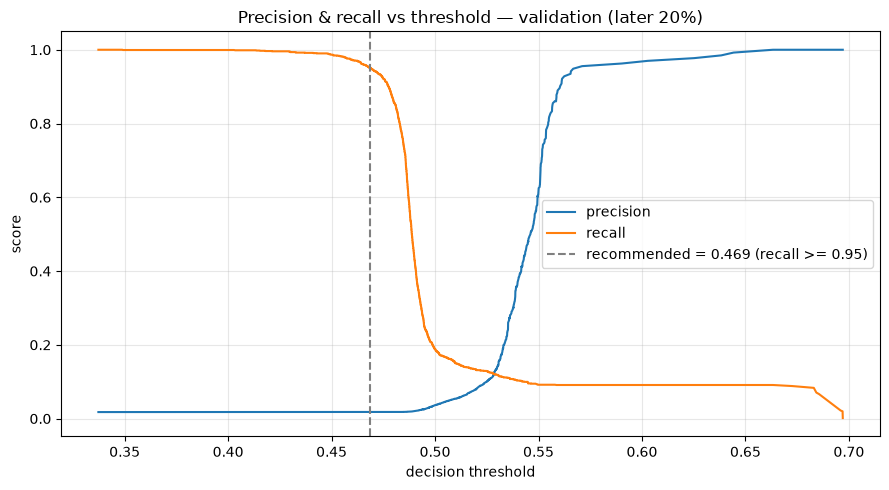


Per-fraud-type recall at recommended threshold (reporting only):
                    recall  count
fraud_type                       
C2_EXFILTRATION     0.8955    134
FIRST_PARTY_FRAUD   0.9161    143
CARD_NOT_PRESENT    0.9478    134
INSIDER_THREAT      0.9500    140
SMURFING            0.9507    142
SYNTHETIC_IDENTITY  0.9552    134
SOCIAL_ENGINEERING  0.9595    148
SIM_SWAP            0.9669    151
ACCOUNT_TAKEOVER    0.9766    128
MONEY_MULE          0.9815    162


In [9]:
fraud_proba = model.predict_proba(X_val)[:, 1]     # P(fraud) in [0,1] — the ensemble input

pr_auc  = average_precision_score(y_val, fraud_proba)
roc_auc = roc_auc_score(y_val, fraud_proba)
print(f"[CHECKPOINT] PR-AUC (primary) = {pr_auc:.4f} | ROC-AUC = {roc_auc:.4f}")

# Reference point only — 0.5 is NOT the operating threshold.
y_pred_05 = (fraud_proba >= 0.5).astype(int)
print(f"\n--- at default 0.5 (reference only) ---")
print(f"precision={precision_score(y_val, y_pred_05):.4f}  "
      f"recall={recall_score(y_val, y_pred_05):.4f}  f1={f1_score(y_val, y_pred_05):.4f}")
print("confusion matrix [[TN FP] [FN TP]]:")
print(confusion_matrix(y_val, y_pred_05))
print(classification_report(y_val, y_pred_05, target_names=["legit", "fraud"], digits=4))

# Operating threshold: highest threshold still achieving recall >= 0.95 (higher
# threshold = fewer false alarms, so take the best precision that keeps the target).
precisions, recalls, thresholds = precision_recall_curve(y_val, fraud_proba)
ok = recalls[:-1] >= 0.95                     # recalls has len(thresholds)+1; last entry is recall=0
RECOMMENDED_THRESHOLD = float(thresholds[ok][-1]) if ok.any() else 0.5
idx = np.where(ok)[0][-1] if ok.any() else 0
print(f"[CHECKPOINT] Recommended threshold = {RECOMMENDED_THRESHOLD:.4f} -> "
      f"recall = {recalls[idx]:.4f}, precision = {precisions[idx]:.4f} "
      "(saved for the ensemble/decision layer — NOT 0.5)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label="precision")
ax.plot(thresholds, recalls[:-1], label="recall")
ax.axvline(RECOMMENDED_THRESHOLD, color="grey", ls="--",
           label=f"recommended = {RECOMMENDED_THRESHOLD:.3f} (recall >= 0.95)")
ax.set_xlabel("decision threshold"); ax.set_ylabel("score")
ax.set_title("Precision & recall vs threshold — validation (later 20%)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# fraud_type: REPORTING ONLY (never a feature) — which fraud patterns does the model catch?
val_report = df.iloc[SPLIT_IDX:][["txn_id"]].copy()
val_report["is_fraud"] = y_val.values
val_report["caught"]   = (fraud_proba >= RECOMMENDED_THRESHOLD).astype(int)
val_report = val_report.merge(fraud_type_report, on="txn_id", how="left")
by_type = (val_report[val_report["is_fraud"] == 1]
           .groupby("fraud_type")["caught"].agg(["mean", "count"])
           .rename(columns={"mean": "recall"}).sort_values("recall"))
print("\nPer-fraud-type recall at recommended threshold (reporting only):")
print(by_type.round(4))


## Step 9 — SHAP explainability (per-decision explanations)

Global view: which features drive the model overall (bar summary on ~2000 validation
rows — TreeExplainer is exact for XGBoost, the sample only bounds plot time).
Per-decision: `explain_transaction()` returns the top-8 signed contributions for one
row — this is exactly what the Behavior Agent logs alongside each verdict.


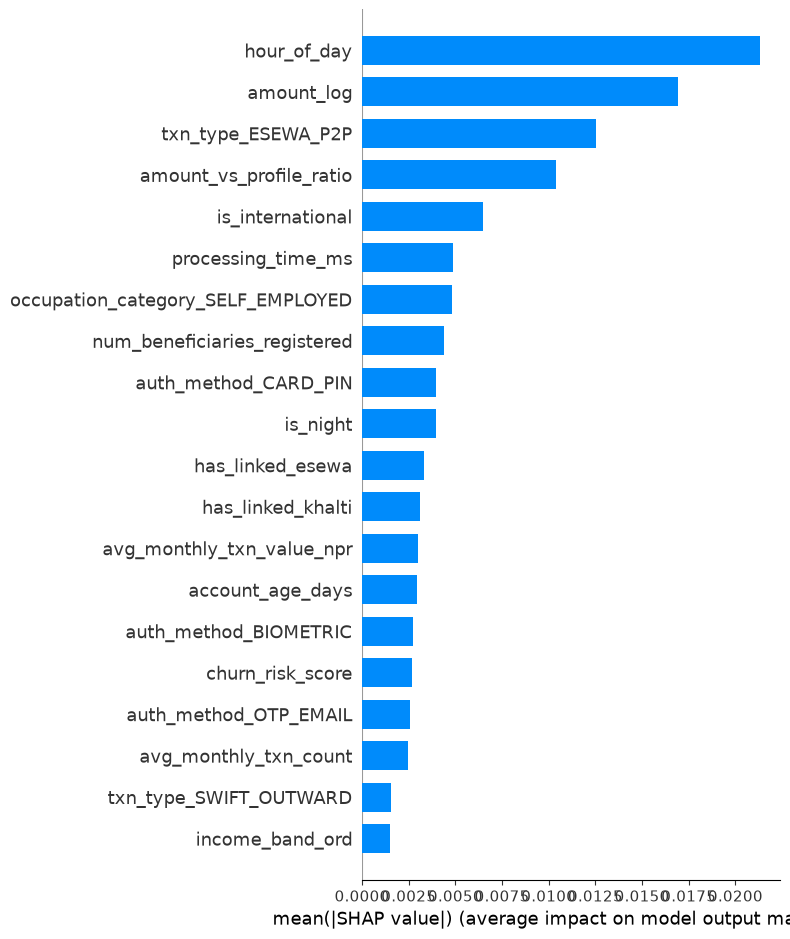

[CHECKPOINT] Demo — val fraud txn scored 0.6970, top-8 drivers:
  is_international                         shap=+0.3756  value=1.000
  amount_log                               shap=+0.3016  value=10.710
  hour_of_day                              shap=+0.0965  value=2.000
  txn_type_SWIFT_OUTWARD                   shap=+0.0406  value=1.000
  is_night                                 shap=+0.0268  value=1.000
  num_beneficiaries_registered             shap=-0.0075  value=49.000
  avg_monthly_txn_value_npr                shap=-0.0069  value=1876898.080
  txn_type_ESEWA_P2P                       shap=-0.0065  value=0.000


In [10]:
explainer = shap.TreeExplainer(model)

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_val), size=min(2000, len(X_val)), replace=False)
X_shap = X_val.iloc[sample_idx]
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=20, show=True)


def explain_transaction(feature_row, top_n=8):
    """Top-N signed SHAP contributions for ONE transaction's feature row.

    Args:
        feature_row: pd.Series or 1-row DataFrame with exactly FEATURE_COLS (in order).
    Returns:
        list of dicts [{feature, shap_value, feature_value}], |shap| descending.
        Positive shap_value pushes toward fraud, negative toward legit.
        This is the payload the Behavior Agent logs per verdict.
    """
    row = feature_row.to_frame().T if isinstance(feature_row, pd.Series) else feature_row
    row = row[FEATURE_COLS]                       # enforce training column order
    sv = explainer.shap_values(row)[0]
    order = np.argsort(-np.abs(sv))[:top_n]
    return [
        {"feature": FEATURE_COLS[i],
         "shap_value": round(float(sv[i]), 5),
         "feature_value": float(row.iloc[0, i])}
        for i in order
    ]


# Demo on the highest-scored validation fraud — the per-verdict log line.
demo_pos = int(np.argmax(np.where(y_val.values == 1, fraud_proba, -1)))
demo = explain_transaction(X_val.iloc[demo_pos])
print(f"[CHECKPOINT] Demo — val fraud txn scored {fraud_proba[demo_pos]:.4f}, top-8 drivers:")
for d in demo:
    print(f"  {d['feature']:<40} shap={d['shap_value']:+.4f}  value={d['feature_value']:.3f}")


## Step 10 — Save artifacts + read-back verification

Same `models/` folder and manifest style as the Isolation Forest branch. Drive writes
have truncated before, so **every** artifact is read back and re-verified before we
call this done. The scored validation set goes to `datasets_processed/` so the ensemble
blend has a ready input to join (on `txn_id`) against the Isolation Forest scores.


In [11]:
MODEL_PATH    = os.path.join(MODEL_DIR, "xgboost_behavior.json")
MANIFEST_PATH = os.path.join(MODEL_DIR, "model_feature_list.json")
SCORED_PATH   = os.path.join(PROCESSED_DIR, "val_scored_xgboost.csv")

model.save_model(MODEL_PATH)   # XGBoost-native JSON: portable, version-stable, no pickle risk

# Exact column order matters at inference — the booster was fit on this order.
manifest = {
    "model_file": "xgboost_behavior.json",
    "feature_columns": FEATURE_COLS,                     # exact order for inference
    "scale_pos_weight": scale_pos_weight,
    "recommended_threshold": RECOMMENDED_THRESHOLD,      # recall>=0.95 point, NOT 0.5
    "best_iteration": int(model.best_iteration),
    "val_pr_auc": float(pr_auc),
    "val_roc_auc": float(roc_auc),
    "random_state": RANDOM_STATE,
    "trained_rows": int(len(X_train)),
    "train_cutoff_timestamp": str(df["timestamp"].iloc[SPLIT_IDX - 1]),
    "role": ("Supervised high-confidence branch of the Behavior Agent ensemble. "
             "Outputs P(fraud) in [0,1] via predict_proba. Weight heavily for accounts "
             "with history; lean on the Isolation Forest branch for cold-start. "
             "Blend joins val_scored_xgboost.csv to the Isolation Forest scores on txn_id."),
}
with open(MANIFEST_PATH, "w") as f:
    json.dump(manifest, f, indent=2)

# Scored val set — same join-on-txn_id spirit as transactions_scored_isoforest.csv.
scored = pd.DataFrame({
    "txn_id": df["txn_id"].iloc[SPLIT_IDX:].values,
    "fraud_proba": fraud_proba,
    "is_fraud": y_val.values,
})
scored.to_csv(SCORED_PATH, index=False)

# --- read-back verification (Drive has truncated writes before) ---
model_back = XGBClassifier()
model_back.load_model(MODEL_PATH)
manifest_back = json.load(open(MANIFEST_PATH))
scored_back = pd.read_csv(SCORED_PATH)

assert model_back.n_features_in_ == len(FEATURE_COLS), "model read-back: feature count mismatch"
assert manifest_back["feature_columns"] == FEATURE_COLS, "manifest read-back mismatch"
assert len(scored_back) == len(X_val), f"scored CSV truncated: {len(scored_back):,} != {len(X_val):,}"
# The reloaded booster must reproduce the live model's probabilities exactly.
proba_back = model_back.predict_proba(X_val.iloc[:100])[:, 1]
assert np.allclose(proba_back, fraud_proba[:100], atol=1e-6), "read-back predictions diverge"

print("[CHECKPOINT] All artifacts saved and verified by read-back:")
print(f"  model    : {MODEL_PATH} ({model_back.n_features_in_} features)")
print(f"  manifest : {MANIFEST_PATH} (threshold={manifest_back['recommended_threshold']:.4f})")
print(f"  scored   : {SCORED_PATH} ({len(scored_back):,} rows)")
print("\nDONE — supervised branch complete. Ensemble contract: P(fraud) in [0,1] per txn_id;")
print("XGBoost = high-confidence supervised branch (accounts with history), Isolation Forest")
print("covers cold-start; blend = clean join on txn_id.")


[CHECKPOINT] All artifacts saved and verified by read-back:
  model    : /Users/dikshanta/Documents/Agentic-Fraud-Detection-System-/backend/models/xgboost_behavior.json (87 features)
  manifest : /Users/dikshanta/Documents/Agentic-Fraud-Detection-System-/backend/models/model_feature_list.json (threshold=0.4688)
  scored   : /Users/dikshanta/Documents/Agentic-Fraud-Detection-System-/backend/datasets_processed/val_scored_xgboost.csv (80,000 rows)

DONE — supervised branch complete. Ensemble contract: P(fraud) in [0,1] per txn_id;
XGBoost = high-confidence supervised branch (accounts with history), Isolation Forest
covers cold-start; blend = clean join on txn_id.
